## Analysis of reported snakebite cases in Brazil between 2000 and 2022

To examine how the number of snakebites changes over time in each state, the number of snakebites is plotted against time and the growth rate year by year is calculated using the formula below:

pct_change =  (current year-previous year)/(previous year)*100

A pie chart showing snakebite frequency (considering the total number of snakebites from 2000 to 2022) by region is plotted to investigate the variation in snakebites cases across different regions in Brazil.

For the statical analysis, a Kruskal-Wallis Test is run to evaluate if there are significant differences in the total number of snakebites between regions, and a Dunn's test is performed for pairwise comparisons.

A map of snakebite frequency by state in Brazil is plotted to help to visualise the state with the highest number of snakebite cases. Also, a heatmap is created considering the geolocation of the states and their total number of snakebites.

A spatial cluster analysis is done using KMeans algorithm to identify the concentration of neighbour states with a high number of snakebites and the silhouette score is calculated to assess the quality of the clustering model.

In [20]:
pip install pandas numpy matplotlib seaborn geopandas folium plotly scikit-posthocs


Note: you may need to restart the kernel to use updated packages.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
from folium.plugins import HeatMap
from matplotlib.colors import Normalize
import plotly.express as px

In [22]:
data = pd.read_csv("./Snakebite cases in Brazil between 2000-2022 new format.csv")

In [23]:
data

,State,Region,Year,Snakebite cases,Latitude,Longitude
0,Rondonia,Norte,2000,293,-11.640027,-61.209995
1,Rondonia,Norte,2001,415,-11.640027,-61.209995
2,Rondonia,Norte,2002,522,-11.640027,-61.209995
3,Rondonia,Norte,2003,740,-11.640027,-61.209995
4,Rondonia,Norte,2004,657,-11.640027,-61.209995
...,...,...,...,...,...,...
616,Distrito Federal,Centro-oeste,2018,122,-15.783340,-47.916052
617,Distrito Federal,Centro-oeste,2019,96,-15.783340,-47.916052
618,Distrito Federal,Centro-oeste,2020,112,-15.783340,-47.916052
619,Distrito Federal,Centro-oeste,2021,111,-15.783340,-47.916052


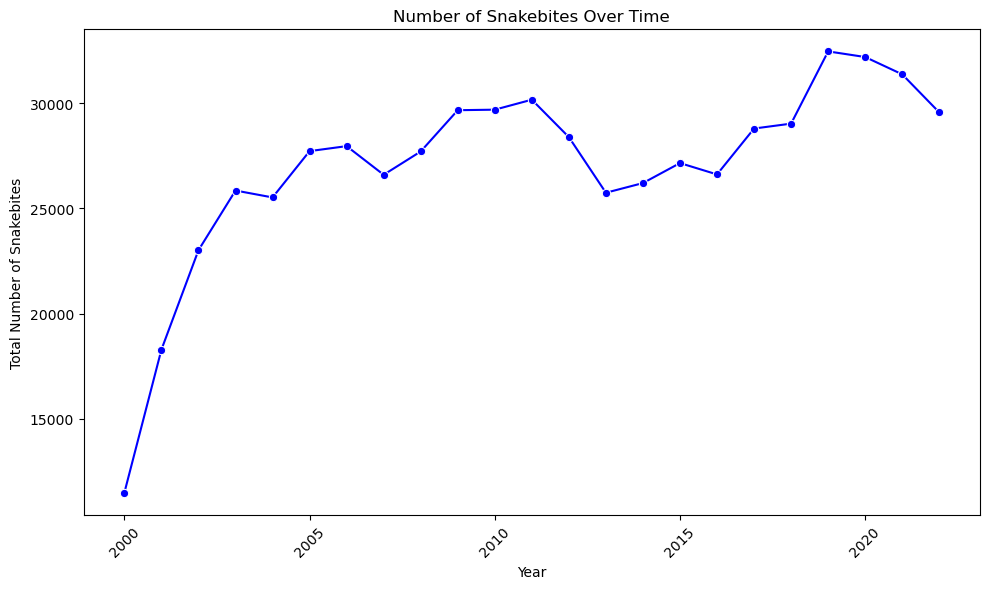

Correlation between Year and Snakebite cases: 0.70


In [24]:
# Analysis number 1

# Summarize the total number of snakebites per year
yearly_bites = data.groupby('Year')['Snakebite cases'].sum().reset_index()

# Plot number of snakebites over time
plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_bites, x='Year', y='Snakebite cases', marker='o', color='b')
plt.title('Number of Snakebites Over Time')
plt.xlabel('Year')
plt.ylabel('Total Number of Snakebites')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate the correlation between Year and Snakebite cases
correlation = yearly_bites['Year'].corr(yearly_bites['Snakebite cases'])
print(f"Correlation between Year and Snakebite cases: {correlation:.2f}")

In [25]:
# Analysis number 2

# Calculate growth rate year by year
yearly_bites['growth_rate'] = yearly_bites['Snakebite cases'].pct_change() * 100

# Show growth rate
print(yearly_bites)


    Year  Snakebite cases  growth_rate
0   2000            11479          NaN
1   2001            18283    59.273456
2   2002            23011    25.860089
3   2003            25849    12.333232
4   2004            25521    -1.268908
5   2005            27724     8.632107
6   2006            27961     0.854855
7   2007            26599    -4.871070
8   2008            27706     4.161811
9   2009            29670     7.088717
10  2010            29695     0.084260
11  2011            30170     1.599596
12  2012            28390    -5.899901
13  2013            25744    -9.320183
14  2014            26204     1.786824
15  2015            27155     3.629217
16  2016            26615    -1.988584
17  2017            28798     8.202142
18  2018            29031     0.809084
19  2019            32467    11.835624
20  2020            32199    -0.825454
21  2021            31376    -2.555980
22  2022            29566    -5.768740


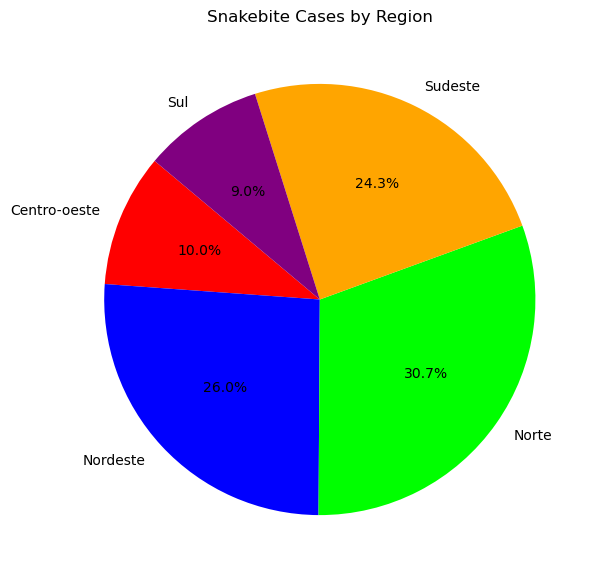

In [26]:
# Analysis number 3

# Summarize the total number of snakebites per region
region_bites = data.groupby('Region')['Snakebite cases'].sum().reset_index()

# Setting the data
labels = region_bites['Region']
sizes = region_bites['Snakebite cases']
colors = ['#FF0000', '#0000FF', '#00FF00', '#FFA500', '#800080']

# Create pie chart
plt.figure(figsize=(7, 7))  
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title("Snakebite Cases by Region")
plt.show()

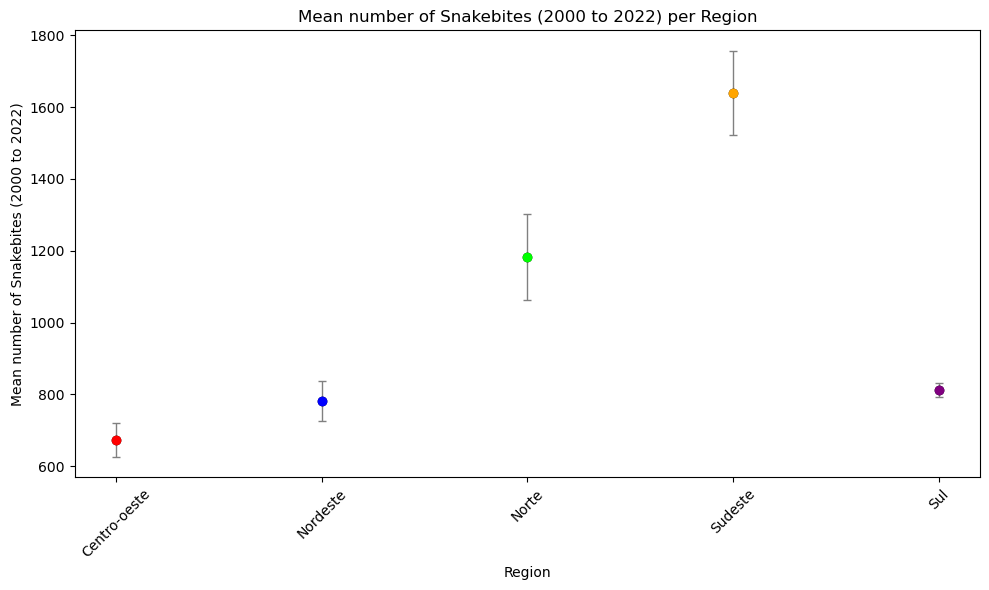

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Analysis number 4

# Group by Region and calculate the mean of the number of snakebites
region_bites = data.groupby('Region')['Snakebite cases'].mean().reset_index()

# Standard deviation and standard error for each region
std_dev = data.groupby('Region')['Snakebite cases'].std()
count = data.groupby('Region')['Snakebite cases'].count()  # Number of entries per region
std_error = std_dev / np.sqrt(count)  # Standard error

# Color map for categorical data (Region)
color_map = {'Norte': '#00FF00', 'Nordeste': '#0000FF', 'Centro-oeste': '#FF0000', 'Sudeste': '#FFA500', 'Sul' : '#800080'}

# Map colors based on the 'Region' column
colors = region_bites['Region'].map(color_map)

# Plot total number of snakebites per region with error bars
plt.figure(figsize=(10, 6))
plt.errorbar(region_bites['Region'], region_bites['Snakebite cases'], yerr=std_error, fmt='o', color='black', 
             ecolor='gray', elinewidth=1, capsize=3)

# Apply colors to each point
for i, region in enumerate(region_bites['Region']):
    plt.scatter(region_bites['Region'][i], region_bites['Snakebite cases'][i], color=colors[i], zorder=5)

# Title and labels
plt.title('Mean number of Snakebites (2000 to 2022) per Region')
plt.xlabel('Region')
plt.ylabel('Mean number of Snakebites (2000 to 2022)')
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()


Checking normality for Centro-oeste:
  Shapiro-Wilk Test: p-value = 0.0000
  The data is not normally distributed.


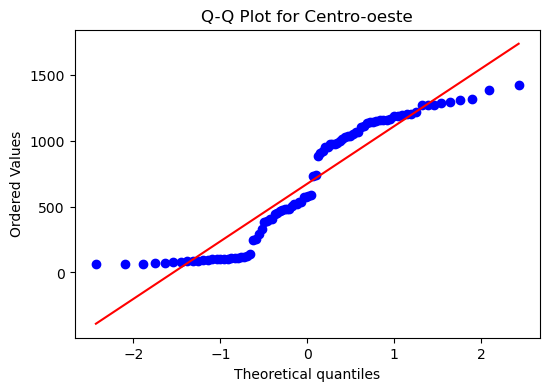

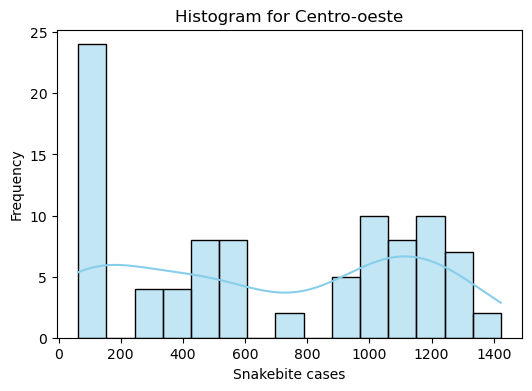



Checking normality for Nordeste:
  Shapiro-Wilk Test: p-value = 0.0000
  The data is not normally distributed.


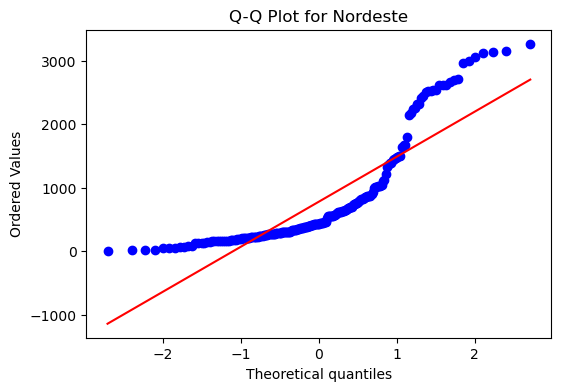

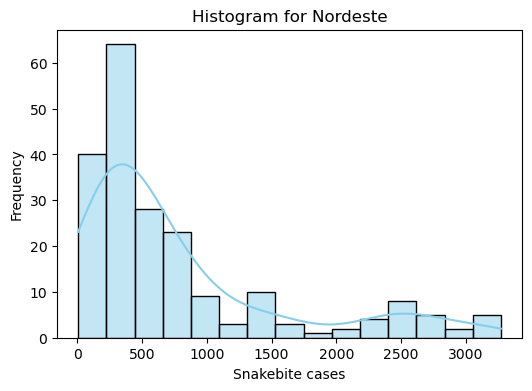



Checking normality for Norte:
  Shapiro-Wilk Test: p-value = 0.0000
  The data is not normally distributed.


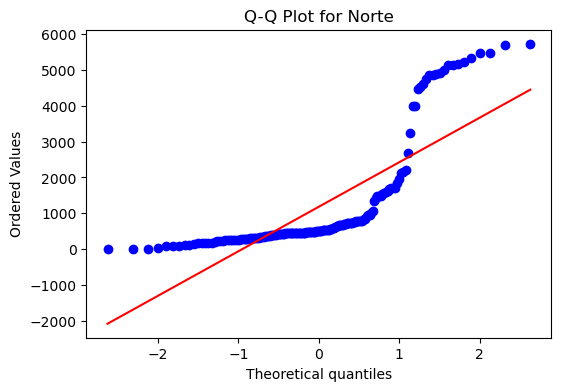

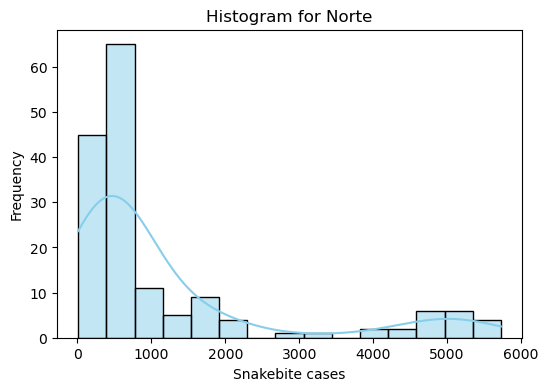



Checking normality for Sudeste:
  Shapiro-Wilk Test: p-value = 0.0000
  The data is not normally distributed.


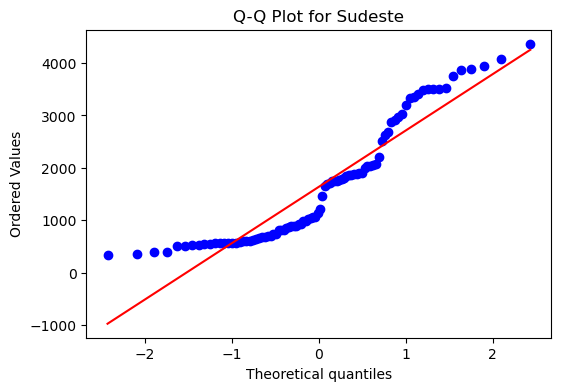

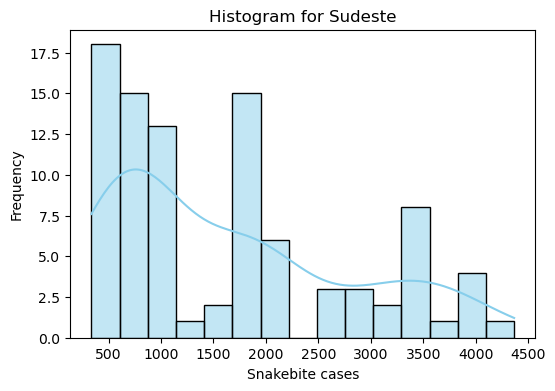



Checking normality for Sul:
  Shapiro-Wilk Test: p-value = 0.0001
  The data is not normally distributed.


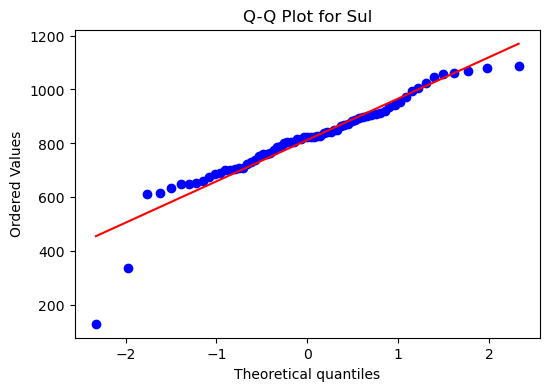

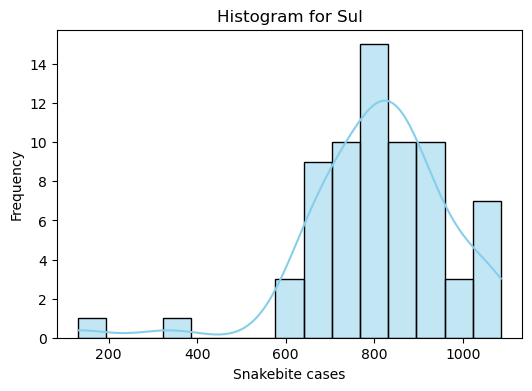

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Group the data by region
regions_data = data.groupby('Region')['Snakebite cases']

# Normality check for each region
for region, snakebites in regions_data:
    print(f"Checking normality for {region}:")
    
    # 1. Shapiro-Wilk Test
    stat, p_value = stats.shapiro(snakebites)
    print(f"  Shapiro-Wilk Test: p-value = {p_value:.4f}")
    
    # Interpret the result of Shapiro-Wilk
    if p_value < 0.05:
        print("  The data is not normally distributed.")
    else:
        print("  The data is normally distributed.")
    
    # 2. Q-Q Plot
    plt.figure(figsize=(6, 4))
    stats.probplot(snakebites, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot for {region}")
    plt.show()

    # 3. Histogram
    plt.figure(figsize=(6, 4))
    sns.histplot(snakebites, kde=True, bins=15, color='skyblue')
    plt.title(f"Histogram for {region}")
    plt.xlabel("Snakebite cases")
    plt.ylabel("Frequency")
    plt.show()

    print("\n")


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scikit_posthocs as sp

#Analysis number 5

# Group the data by Region
regions_data = data.groupby('Region')['Snakebite cases'].apply(list)

# Kruskal-Wallis Test
kruskal_results = stats.kruskal(*regions_data)

print(f"Kruskal-Wallis Test Results:")
print(f"  H-statistic: {kruskal_results.statistic}")
print(f"  p-value: {kruskal_results.pvalue}")

# Interpretation of Kruskal-Wallis result
alpha = 0.05  # significance level (5%)
if kruskal_results.pvalue < alpha:
    print("There are significant differences in the number of snakebites between regions.")
    
    # Perform Dunn's test for pairwise comparisons
    dunn_results = sp.posthoc_dunn(data, val_col='Snakebite cases', group_col='Region', p_adjust='bonferroni')
    
    print("\nDunn's Test Results (Pairwise Comparisons):")
    print(dunn_results)
else:
    print("There are no significant differences in the number of snakebites between regions.")


Kruskal-Wallis Test Results:
  H-statistic: 77.34693616868928
  p-value: 6.350769950595164e-16
There are significant differences in the number of snakebites between regions.

Dunn's Test Results (Pairwise Comparisons):
              Centro-oeste      Nordeste         Norte       Sudeste       Sul
Centro-oeste  1.000000e+00  1.000000e+00  1.000000e+00  1.677210e-08  0.021382
Nordeste      1.000000e+00  1.000000e+00  5.369362e-01  4.225297e-15  0.000084
Norte         1.000000e+00  5.369362e-01  1.000000e+00  4.231888e-09  0.037844
Sudeste       1.677210e-08  4.225297e-15  4.231888e-09  1.000000e+00  0.121087
Sul           2.138153e-02  8.364264e-05  3.784377e-02  1.210870e-01  1.000000


In [30]:
import geopandas as gpd

# Load shapefile of Brazilian states
brazil_shapefile = gpd.read_file('./BR_UF_2023.shp')

# Check the first few rows
print(brazil_shapefile)


   CD_UF                State SIGLA_UF CD_REGIAO        Region     AREA_KM2  \
0     11             Rondonia       RO         1         Norte   237754.171   
1     12                 Acre       AC         1         Norte   164173.525   
2     13             Amazonas       AM         1         Norte  1559256.365   
3     14              Roraima       RR         1         Norte   223644.534   
4     15                 Para       PA         1         Norte  1245870.242   
5     16                Amapa       AP         1         Norte   142470.762   
6     17            Tocantins       TO         1         Norte   277423.627   
7     21             Maranhao       MA         2      Nordeste   329651.495   
8     22                Piaui       PI         2      Nordeste   251755.481   
9     23                Ceara       CE         2      Nordeste   148894.447   
10    24  Rio Grande do Norte       RN         2      Nordeste    52809.599   
11    25            Sao Paulo       PB         2    

In [31]:
# Rename columns and State names to match data
brazil_shapefile = brazil_shapefile.rename(columns={'NM_UF': 'State'})
brazil_shapefile = brazil_shapefile.rename(columns={'NM_REGIAO': 'Region'})
brazil_shapefile.loc[brazil_shapefile['State'] == 'Rondônia', 'State'] = 'Rondonia'
brazil_shapefile.loc[brazil_shapefile['State'] == 'Pará', 'State'] = 'Para'
brazil_shapefile.loc[brazil_shapefile['State'] == 'Amapá', 'State'] = 'Amapa'
brazil_shapefile.loc[brazil_shapefile['State'] == 'Piauí', 'State'] = 'Piaui'
brazil_shapefile.loc[brazil_shapefile['State'] == 'Ceará', 'State'] = 'Ceara'
brazil_shapefile.loc[brazil_shapefile['State'] == 'Paraíba', 'State'] = 'Paraiba'
brazil_shapefile.loc[brazil_shapefile['State'] == 'Maranhão', 'State'] = 'Maranhao'
brazil_shapefile.loc[brazil_shapefile['State'] == 'Espírito Santo', 'State'] = 'Espirito Santo'
brazil_shapefile.loc[brazil_shapefile['State'] == 'São Paulo', 'State'] = 'Sao Paulo'
brazil_shapefile.loc[brazil_shapefile['State'] == 'Paraná', 'State'] = 'Parana'
brazil_shapefile.loc[brazil_shapefile['State'] == 'Goiás', 'State'] = 'Goias'

# Print to confirm the change
print(brazil_shapefile)

# Save the updated shapefile 
brazil_shapefile.to_file('./BR_UF_2023.shp')

   CD_UF                State SIGLA_UF CD_REGIAO        Region     AREA_KM2  \
0     11             Rondonia       RO         1         Norte   237754.171   
1     12                 Acre       AC         1         Norte   164173.525   
2     13             Amazonas       AM         1         Norte  1559256.365   
3     14              Roraima       RR         1         Norte   223644.534   
4     15                 Para       PA         1         Norte  1245870.242   
5     16                Amapa       AP         1         Norte   142470.762   
6     17            Tocantins       TO         1         Norte   277423.627   
7     21             Maranhao       MA         2      Nordeste   329651.495   
8     22                Piaui       PI         2      Nordeste   251755.481   
9     23                Ceara       CE         2      Nordeste   148894.447   
10    24  Rio Grande do Norte       RN         2      Nordeste    52809.599   
11    25            Sao Paulo       PB         2    

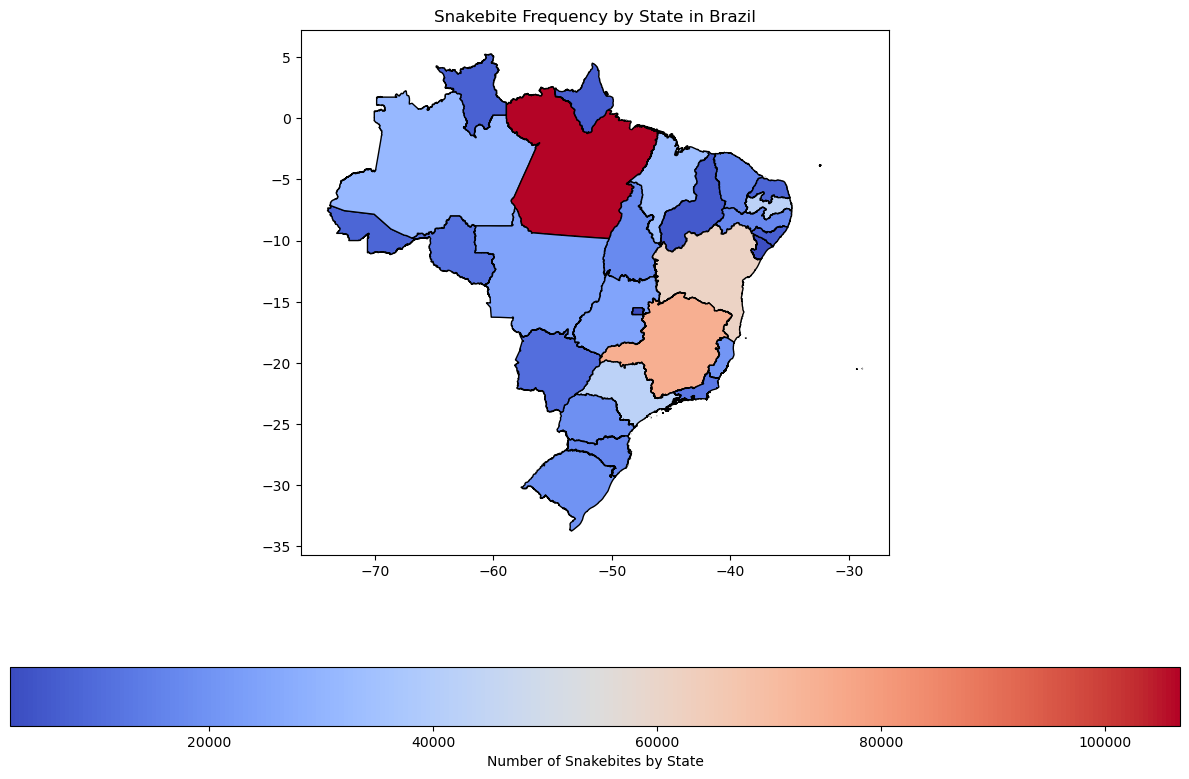

In [32]:
# Analysis number 6A

# Merge snakebite data with shapefile by state
merged_data = brazil_shapefile.merge(
    data.groupby('State')['Snakebite cases'].sum().reset_index(),
    how='left', on='State')

# Plotting the map of snakebites by state
fig, ax = plt.subplots(figsize=(12, 8))
merged_data.plot(column='Snakebite cases', ax=ax, legend=True,
                 legend_kwds={'label': "Number of Snakebites by State",
                              'orientation': "horizontal"},
                 cmap='coolwarm', edgecolor='black')
ax.set_title("Snakebite Frequency by State in Brazil")
plt.tight_layout()
plt.show()


In [33]:
# Analysis number 6B

# Create a map centered around Brazil
m = folium.Map(location=[-14.2350, -51.9253], zoom_start=4)

# Create a DataFrame with latitude, longitude, and total snakebites
heatmap_data = data.groupby(['Latitude', 'Longitude'])['Snakebite cases'].sum().reset_index()

# Convert to list of lists for heatmap
heat_data = heatmap_data[['Latitude', 'Longitude', 'Snakebite cases']].values.tolist()

# Add HeatMap to the folium map
HeatMap(heat_data).add_to(m)

# Display the map
m.save('snakebite_heatmap.html')  # Save the heatmap as an HTML file to view in a browser


C:\Users\gx24723\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


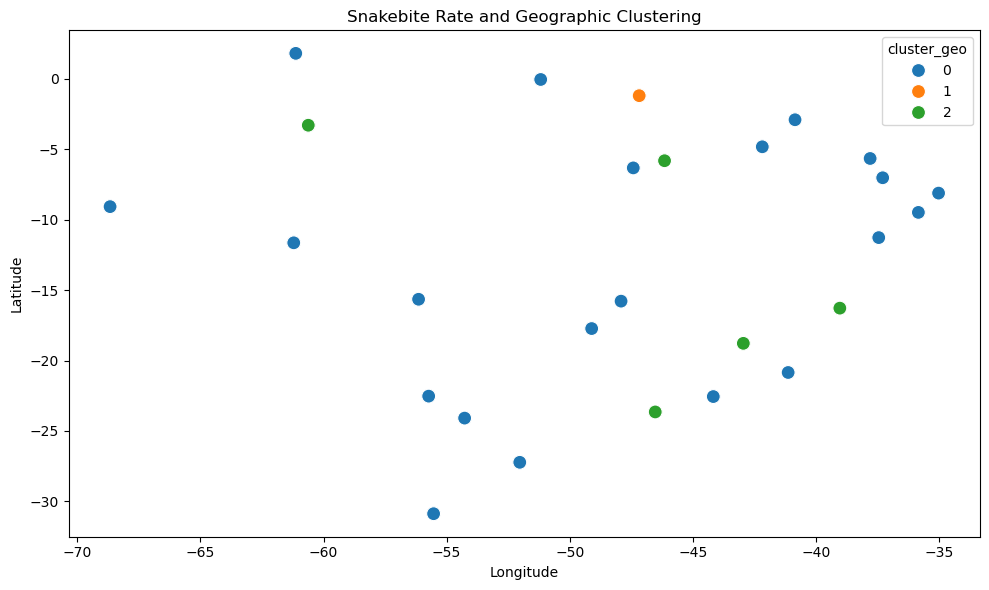

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

#Analysis number 7A

# Combine geographic and snakebite data
X_geo = data[['Snakebite cases', 'Latitude', 'Longitude']].values

# Apply KMeans clustering to both features (snakebite rate + geographic coordinates)
kmeans_geo = KMeans(n_clusters=3, random_state=42)
data['cluster_geo'] = kmeans_geo.fit_predict(X_geo)

# Visualize clustering based on geographic location + snakebite rate
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Longitude', y='Latitude', hue='cluster_geo', palette='tab10', data=data, s=100)
plt.title('Snakebite Rate and Geographic Clustering')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()


In [35]:
from sklearn.metrics import silhouette_score

#Analysis number 7B

# Calculate the silhouette score for KMeans clustering
score = silhouette_score(X_geo, kmeans_geo.labels_)
print(f'Silhouette Score: {score}')


Silhouette Score: 0.676600443021591


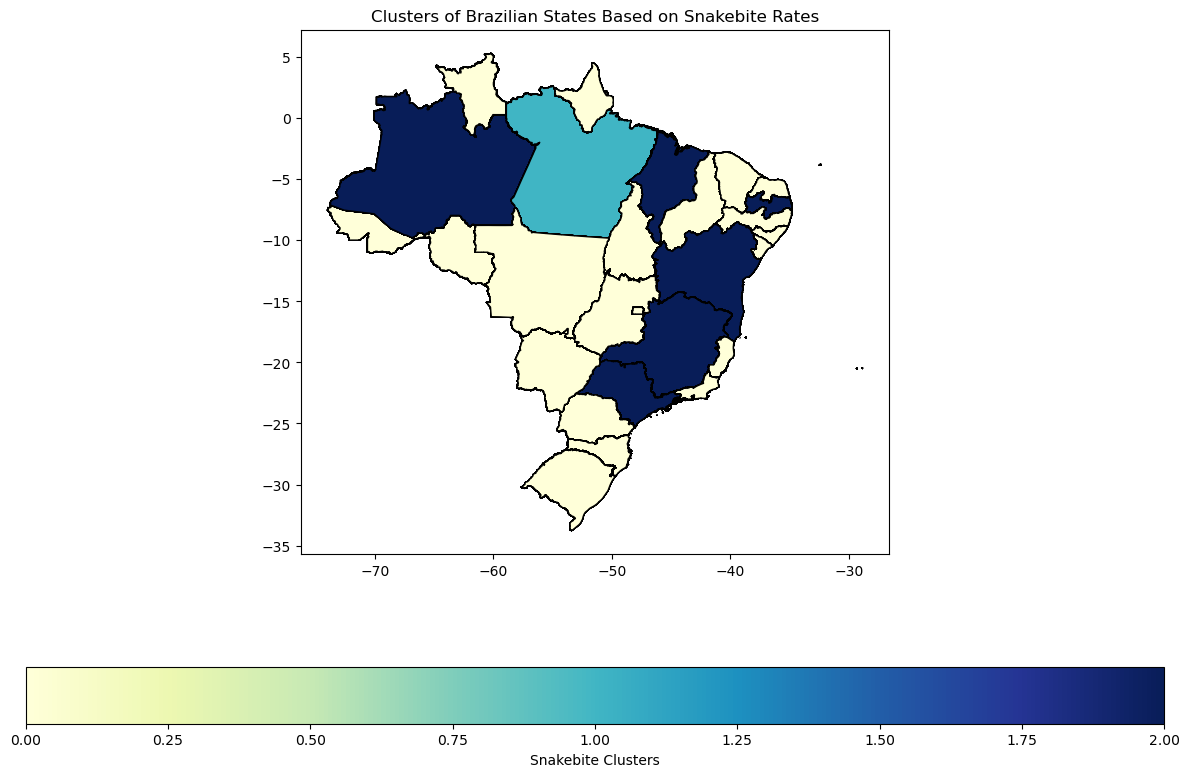

In [36]:
import geopandas as gpd
import matplotlib.pyplot as plt

#Analysis number 7C

# Load the shapefile and merge with clustering results
shapefile = gpd.read_file('./BR_UF_2023.shp')
shapefile = shapefile.merge(data, left_on='State', right_on='State')

# Plot the map with clustering
fig, ax = plt.subplots(figsize=(12, 8))
shapefile.plot(column='cluster_geo', ax=ax, legend=True,
              legend_kwds={'label': "Snakebite Clusters", 'orientation': "horizontal"},
              cmap='YlGnBu', edgecolor='black')
ax.set_title('Clusters of Brazilian States Based on Snakebite Rates')
plt.tight_layout()
plt.show()
